In [1]:
import filamentprocessing

Filament Processing module initialized


In [2]:
import numpy as np
from scipy.io import loadmat
from pathlib import Path
import pickle
import networkx as nx
from matplotlib import pyplot as plt

linearity_threshold = 0.5
radius_curvature_threshold = 500

rod_data_root_dir = Path('/Users/yeonsu/Data/steel-rods-xray-data')
segments_file_path = rod_data_root_dir / 'alpha200_epsilon00' / 'segments.mat'
mat_obj = loadmat(segments_file_path)
segments = mat_obj['segments']
segments = [seg[0] for seg in segments]
N_segments = len(segments)

for i,segment in enumerate(segments):
    segments[i] = np.array(segment,dtype=np.float64)

print(f'Number of segments: {N_segments}')

Number of segments: 82063


In [3]:
def sort_curve(rr):
    centroid = np.mean(rr,axis=0)
    rr_centered = rr - centroid        
    _,_, V = np.linalg.svd(rr_centered, full_matrices=False)
    v1 = V[0,:]
    orientation = v1 * np.sign(np.sum(v1 * (rr_centered[-1, :] - rr_centered[0, :])))
    slist = np.dot((rr - centroid), orientation)
    sorted_indices = np.argsort(slist)
    return centroid + rr_centered[sorted_indices]

for i,seg in enumerate(segments):
    seg = np.unique(seg,axis=0)
    segments[i] = sort_curve(seg)

Maximum segment length: 3165.0928511317306 at index 71706
Maximum segment error: 12.849134558744497 at index 45841


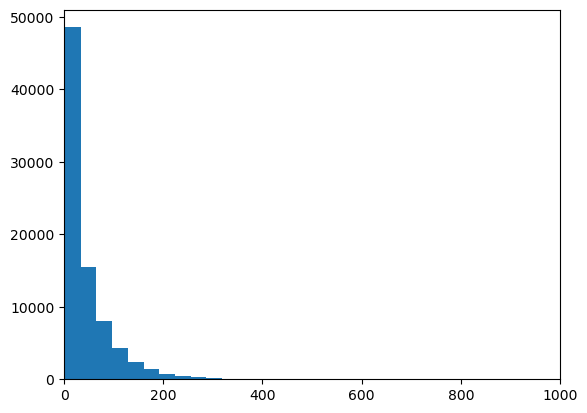

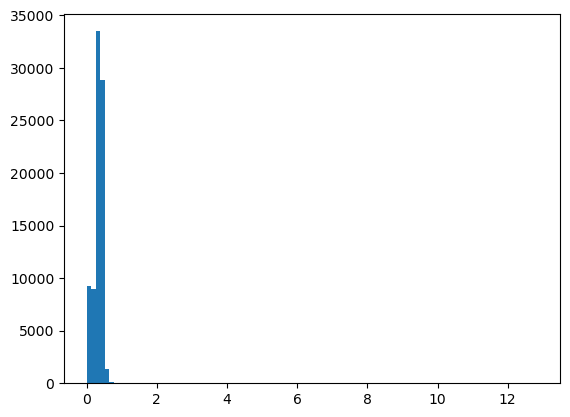

In [4]:
def inspect_segments(segments):
    N_segments = len(segments)
    segments_length_list = np.zeros(N_segments)
    for i,seg in enumerate(segments):
        segments_length_list[i] = np.sum(np.sqrt(np.sum(np.diff(seg,axis=0)**2,axis=1)))   
        
    fig,ax=plt.subplots(1,1)
    ax.hist(segments_length_list,bins=100)
    ax.set_xlim([0,1000])
    
    from fitting import fit_rod

    segments_error_list = np.zeros(N_segments)
    for i,seg in enumerate(segments):
        rr = np.array(seg,dtype=np.float64)
        fit_result = fit_rod(rr,0.00001,10000)
        segments_error_list[i] = fit_result['err']
        
    fig,ax=plt.subplots(1,1)
    ax.hist(segments_error_list,bins=100)
        
    print(f'Maximum segment length: {np.max(segments_length_list)} at index {np.argmax(segments_length_list)}')
    print(f'Maximum segment error: {np.max(segments_error_list)} at index {np.argmax(segments_error_list)}')
    
    return segments_length_list,segments_error_list

segments_length_list,segments_error_list = inspect_segments(segments)

In [5]:
# Ensure connectivity
def edge_lengths(curve):
    return (np.sqrt(np.sum(np.diff(curve,axis=0)**2,axis=1)))

def break_segments(segs):
    new_segments = []
    for seg in segs:
        edge_len = edge_lengths(seg)
        grph = nx.Graph()
        grph.add_nodes_from(range(len(seg)))

        for i in range(len(seg)-1):
            if edge_len[i] <= np.sqrt(3):
                grph.add_edge(i,i+1)
            
        clusters = list(nx.connected_components(grph))
        for i,cluster in enumerate(clusters):
            if len(cluster) == 1:                
                continue
            rr = np.array(seg,dtype=np.float64)            
            new_segments.append(rr[list(cluster)])
        
    return new_segments

new_segments = break_segments(segments)

for i,seg in enumerate(new_segments):
    new_segments[i] = sort_curve(seg)

Maximum segment length: 725.7870908562717 at index 21
Maximum segment error: 6.764672403987392 at index 77188


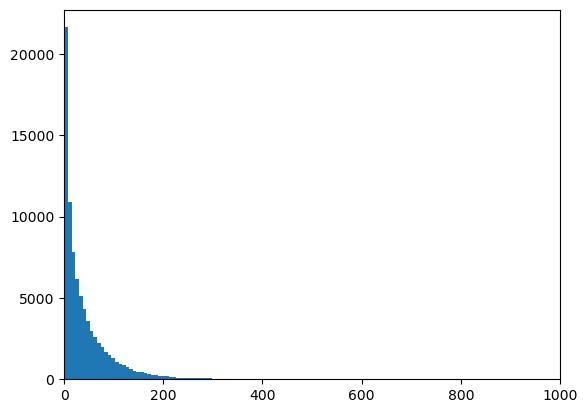

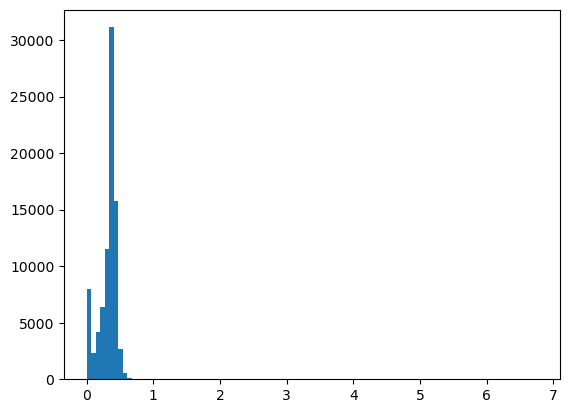

In [6]:
segments_length_list,segments_error_list = inspect_segments(new_segments)


6.764672403987392


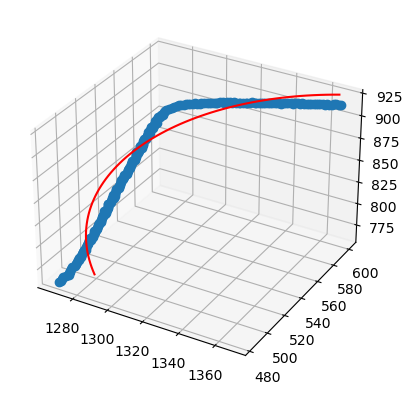

In [7]:
rr = new_segments[77188]

# ax.axis('equal')

import fitting
from fitting import fit_rod
import importlib
importlib.reload(fitting)

fr = fit_rod(rr,0.00001,10000)
print(fr['err'])

rec = fr['rec']


fig,ax=plt.subplots(1,1,subplot_kw={'projection':'3d'})
ax.plot(rr[:,0],rr[:,1],rr[:,2],'o')
ax.plot(rec[:,0],rec[:,1],rec[:,2],'r-')
# vec = rr-rec
# ax.quiver(rr[:,0],rr[:,1],rr[:,2],vec[:,0],vec[:,1],vec[:,2],length=0.1)
# # ax.axis('equal')
# # camera angle
# ax.view_init(azim=45, elev=0)


# 

/var/folders/b9/jhfhzqd55557_wv28nft885r0000gn/T/ipykernel_134/127696810.py:10: RuntimeWarning: divide by zero encountered in divide
  return nom/den


(1212.0, 1424.0, 435.5, 647.5)

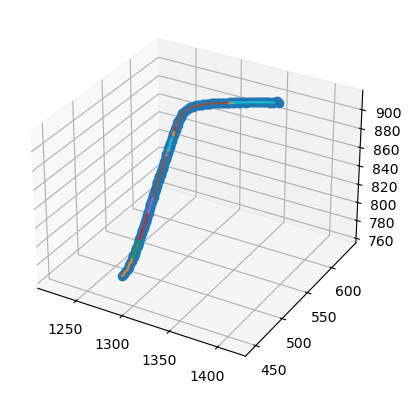

In [8]:
from partition import calculate_curvature

def curvature_of_polygonal_curve(nodes):
    tan2 = nodes[2:,:] - nodes[1:-1,:]    
    tan1 = nodes[1:-1,:] - nodes[:-2,:]
    
    nom = np.linalg.norm(2*np.cross(tan1,tan2,axis=1),axis=1)
    den = np.sum(tan1*tan2,axis=1)
    # curvature = np.sum(nom/den)
    return nom/den

def break_curved_rods(seg,curvature_threshold):
    curvature = curvature_of_polygonal_curve(seg)
    break_points = np.where(np.abs(curvature)>curvature_threshold)[0]
    if len(break_points)==0:
        return [seg]
    else:
        segs = []
        start_idx = 0
        for bp in break_points:
            segs.append(seg[start_idx:bp+1])
            start_idx = bp
        segs.append(seg[start_idx:])
        return segs
    
broken_pieces = break_curved_rods(rr,10)

fig=plt.figure()
ax=fig.add_subplot(111,projection='3d')
ax.plot(rr[:,0],rr[:,1],rr[:,2],'o')
for bp in broken_pieces:
    ax.plot(bp[:,0],bp[:,1],bp[:,2],'-')
ax.axis('equal')

# broken_pieces



/var/folders/b9/jhfhzqd55557_wv28nft885r0000gn/T/ipykernel_134/127696810.py:10: RuntimeWarning: divide by zero encountered in divide
  return nom/den


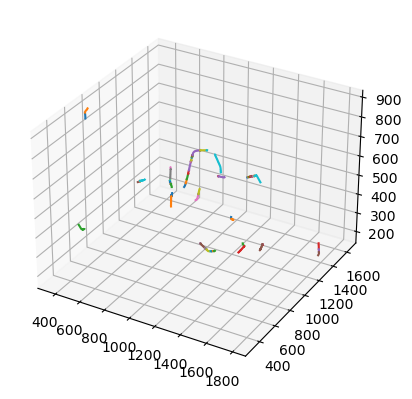

In [9]:
fig,ax=plt.subplots(1,1,subplot_kw={'projection':'3d'})
broken_segments_list = []
for i in np.where(segments_error_list>1)[0]:
    rr = new_segments[i]
    broken_pieces = break_curved_rods(rr,10)    
    for bp in broken_pieces:
        ax.plot(bp[:,0],bp[:,1],bp[:,2])    
        broken_segments_list.append(bp)
        

# delete segments_error_list>1
new_segments2 = [seg for i,seg in enumerate(new_segments) if segments_error_list[i]<=1]
new_segments2 = new_segments2 + broken_segments_list

Maximum segment length: 725.7870908562717 at index 21
Maximum segment error: 1.585782888186731 at index 82769


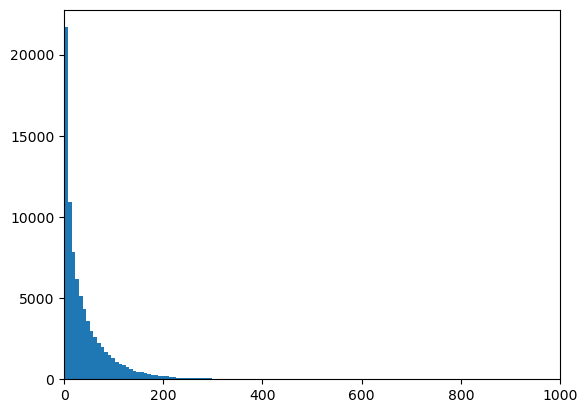

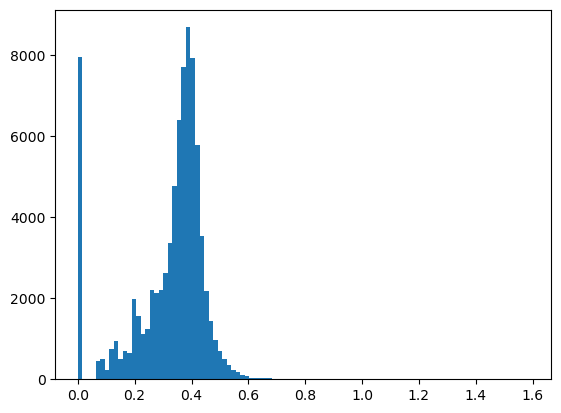

In [10]:
segments = new_segments2
segments_length_list,segments_error_list = inspect_segments(segments)

In [11]:
print(f'Number of segments: {len(segments)}')

Number of segments: 82792


In [12]:
fp = filamentprocessing.FilamentProcessing(segments,2500,0.15)

FilamentProcessing constructor
prepSvdCylinders
Processing filament 0 of 82792
Processing filament 1000 of 82792
Processing filament 2000 of 82792
Processing filament 3000 of 82792
Processing filament 4000 of 82792
Processing filament 5000 of 82792
Processing filament 6000 of 82792
Processing filament 7000 of 82792
Processing filament 8000 of 82792
Processing filament 9000 of 82792
Processing filament 10000 of 82792
Processing filament 11000 of 82792
Processing filament 12000 of 82792
Processing filament 13000 of 82792
Processing filament 14000 of 82792
Processing filament 15000 of 82792
Processing filament 16000 of 82792
Processing filament 17000 of 82792
Processing filament 18000 of 82792
Processing filament 19000 of 82792
Processing filament 20000 of 82792
Processing filament 21000 of 82792
Processing filament 22000 of 82792
Processing filament 23000 of 82792
Processing filament 24000 of 82792
Processing filament 25000 of 82792
Processing filament 26000 of 82792
Processing filament 

In [13]:
fp.calculate_filament_distance_matrix(1000,0.15)

In [14]:
ij = np.array(fp.get_ij())
scores = np.array(fp.get_scores())

print(f'Number of edges: {len(ij)}')

Number of edges: 360013


In [15]:
dist_score = scores[:,0]
align_score = scores[:,1]
fit_score = scores[:,2]

dist_thresh = 50
align_thresh = 0.05
fitting_thresh = 1
mask = (dist_score < dist_thresh) & (align_score < align_thresh) & (fit_score > fitting_thresh)


In [18]:
Graph0 = nx.Graph()
Graph0.add_nodes_from(range(len(segments)))
Graph0.add_weighted_edges_from(zip(ij[mask,0],ij[mask,1],dist_score[mask]))

def find_connected_components(a_graph):
    clusters = list(nx.connected_components(a_graph))
    for i,cluster in enumerate(clusters):
        clusters[i] = np.sort(np.array(list(cluster)).astype(int))        
    return clusters

clusters = find_connected_components(Graph0)


In [19]:
cluster_size_list = [len(cc) for cc in clusters]
print(f'Number of clusters: {len(clusters)}')
print(f'Max cluster size: {max(cluster_size_list)}')
        
cluster_size_list = [len(x) for x in clusters]
max_cluster_size = np.max(cluster_size_list)
print(f'Number of clusters: {len(clusters)}')
print(f'Max cluster size: {max_cluster_size}')

Number of clusters: 81610
Max cluster size: 12
Number of clusters: 81610
Max cluster size: 12


In [20]:
print(np.argsort(cluster_size_list)[::-1])

[  957  8709 20668 ... 54317 54318     0]


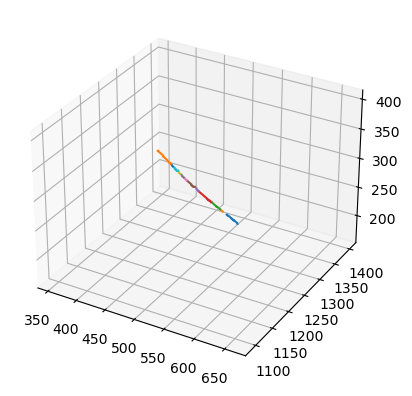

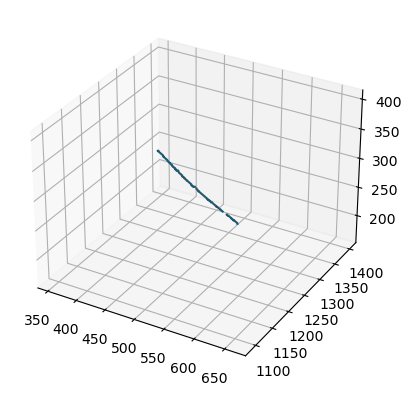

In [21]:
cc = clusters[957]

fig=plt.figure()
ax=fig.add_subplot(111,projection='3d')
for i in cc:
    ax.plot(segments[i][:,0],segments[i][:,1],segments[i][:,2])
ax.axis('equal')

import clustering
from clustering import explode_local_cluster
subclustgers = explode_local_cluster(segments,cc)

fig=plt.figure()
ax=fig.add_subplot(111,projection='3d')
for sc in subclustgers:    
    clr = np.random.rand(3)
    for i in sc:
        ax.plot(segments[cc[i]][:,0],segments[cc[i]][:,1],segments[cc[i]][:,2],color=clr)        
    ax.axis('equal')


In [24]:
# check if common elements exist between clusters
if np.hstack(clusters).size != len(np.unique(np.hstack(clusters))):
    print('Common elements exist between clusters')
        
cluster_size_list = [len(x) for x in clusters]
max_cluster_size = np.max(cluster_size_list)
print(f'Number of clusters: {len(clusters)}')
print(f'Max cluster size: {max_cluster_size}')

cluster_length_list = np.zeros(len(clusters))
for i in range(len(clusters)):
    cluster_length_list[i] = segments_length_list[clusters[i]].sum()/650
np.argsort(cluster_length_list)[::-1]

subcluster_error_threshold = 1
subcluster_length_threshold = 200

good_clusters = []
for i_cluster, a_cluster in enumerate(clusters):
    subclusters = explode_local_cluster(segments,a_cluster)        
    # check quality
    subcluster_error_list = np.zeros(len(subclusters))
    subcluster_length_list = np.zeros(len(subclusters))
    for i_subcluster,subcluster in enumerate(subclusters):
        joined = np.vstack([segments[ a_cluster[iii] ] for iii in subcluster])
        fit_result = fit_rod(joined,linearity_threshold=0.0001,radius_curvature_threshold=100000)
        subcluster_error_list[i_subcluster] = fit_result['err']
        # rec = fit_result['rec']
        subcluster_length_list[i_subcluster] = segments_length_list[ a_cluster[subcluster] ].sum()
    
    certification = (subcluster_error_list < subcluster_error_threshold) & (subcluster_length_list > subcluster_length_threshold)
    
    for i_cert in np.where(certification)[0]:
        good_clusters.append([a_cluster[i] for i in subclusters[i_cert]])

Number of clusters: 81610
Max cluster size: 12


In [27]:

good_nodes = np.hstack(good_clusters)
not_yet_nodes = np.setdiff1d(range(N_segments),good_nodes)
for i_ny in not_yet_nodes:
    rr = segments[i_ny]
    fit_result = fit_rod(rr,linearity_threshold=0.0001,radius_curvature_threshold=100000)
    rr_len = np.sum(np.sqrt(np.sum(np.diff(rr,axis=0)**2,axis=1)))
    
    if fit_result['err'] < 1 and rr_len > 600:
        good_clusters.append(np.array([i_ny]))
        
good_nodes = np.hstack(good_clusters)
not_yet_nodes = np.setdiff1d(range(N_segments),good_nodes)

print(f'Number of good clusters: ', len(good_clusters))
print(f'Number of not yet nodes: ', len(not_yet_nodes))

Number of good clusters:  1709
Number of not yet nodes:  80040


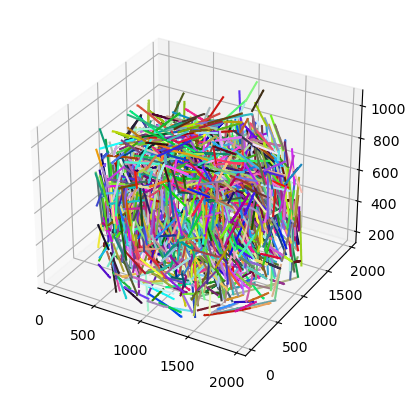

In [28]:
fig,ax=plt.subplots(1,1,subplot_kw={'projection':'3d'})
for gcl in good_clusters:
    clr = np.random.rand(3)
    for i in gcl:
        ax.plot(segments[i][:,0],segments[i][:,1],segments[i][:,2],color=clr)

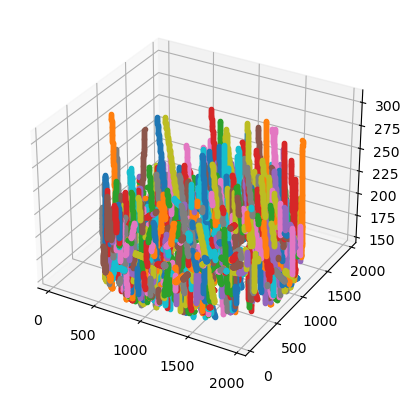

In [42]:
fig,ax=plt.subplots(1,1,subplot_kw={'projection':'3d'})
for i in not_yet_nodes[:1000]:
    ax.plot(segments[i][:,0],segments[i][:,1],segments[i][:,2],'.-')

72456

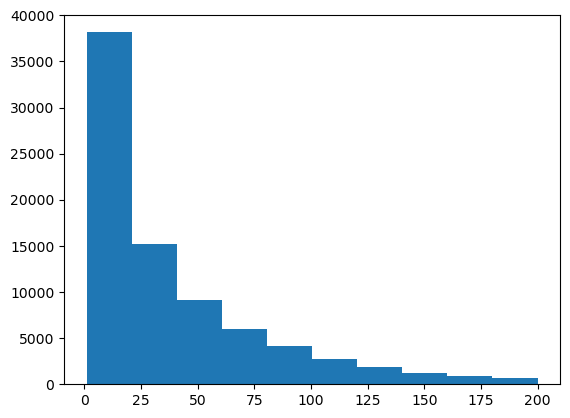

In [51]:
def seg_len(seg):
    return np.sum(np.sqrt(np.sum(np.diff(seg,axis=0)**2,axis=1)))   

not_yet_length_list = []
for i in not_yet_nodes:
    rr = segments[i]
    not_yet_length_list.append(seg_len(rr))
    # if rr.shape[0] > 200:
    #     print(i)
    # if seg_len(rr) > 250:
    #     print(i)
        
fig,ax=plt.subplots(1,1)
ax.hist(not_yet_length_list)

np.argmax(not_yet_length_list)

199.95258984791502


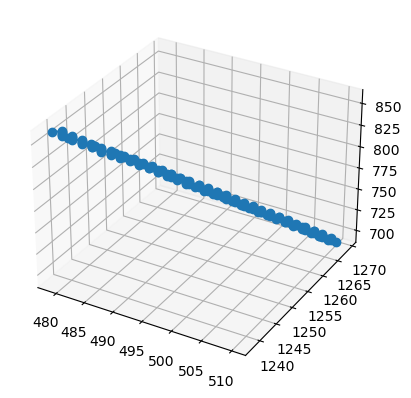

In [55]:
rr = segments[not_yet_nodes[72456]]
fig,ax=plt.subplots(1,1,subplot_kw={'projection': '3d'})
ax.plot(rr[:,0],rr[:,1],rr[:,2],'o-')

print(seg_len(rr))

In [ ]:
def inspect_cluster(clusters,segments):
    N_segments = len(segments)
    segments_length_list = np.zeros(N_segments)
    for i,seg in enumerate(segments):
        segments_length_list[i] = np.sum(np.sqrt(np.sum(np.diff(seg,axis=0)**2,axis=1)))   
        
    fig,ax=plt.subplots(1,1)
    ax.hist(segments_length_list,bins=100)
    ax.set_xlim([0,1000])
    
    from fitting import fit_rod

    segments_error_list = np.zeros(N_segments)
    for i,seg in enumerate(segments):
        rr = np.array(seg,dtype=np.float64)
        fit_result = fit_rod(rr,0.00001,10000)
        segments_error_list[i] = fit_result['err']
        
    fig,ax=plt.subplots(1,1)
    ax.hist(segments_error_list,bins=100)
        
    print(f'Maximum segment length: {np.max(segments_length_list)} at index {np.argmax(segments_length_list)}')
    print(f'Maximum segment error: {np.max(segments_error_list)} at index {np.argmax(segments_error_list)}')
    
    return segments_length_list,segments_error_list